In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import folium
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import warnings

from sklearn.ensemble import RandomForestRegressor

In [32]:
# warnings.filterwarnings('ignore')

# 1. ADATELŐKÉSZÍTÉS
df = pd.read_csv('Map-Crime_Incidents-Previous_Three_Months.csv')
print(len(df))
if 'IncidntNum' in df.columns:
    df = df.drop(columns=['IncidntNum'])
df = df.dropna()
print(len(df))


df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df = df[(df['X'] < -120) & (df['Y'] > 30)]



# --- SÚLYOSSÁGI SKÁLA ÉS ADATGAZDAGÍTÁS (V7 + KOCKÁZAT) ---
category_severity = {
    '1': {"NON-CRIMINAL", "SUSPICIOUS OCC", "MISSING PERSON", "RUNAWAY", "SUICIDE"},
    '2': {"LOITERING", "DRUNKENNESS", "LIQUOR LAWS", "GAMBLING", "DISORDERLY CONDUCT"},
    '3': {"TRESPASS", "VANDALISM", "PROSTITUTION", "PORNOGRAPHY/OBSCENE MAT", "BAD CHECKS"},
    '4': {"FRAUD", "FORGERY/COUNTERFEITING", "EMBEZZLEMENT", "OTHER OFFENSES", "WARRANTS"},
    '5': {"LARCENY/THEFT", "VEHICLE THEFT", "STOLEN PROPERTY", "DRUG/NARCOTIC"},
    '6': {"BURGLARY", "DRIVING UNDER THE INFLUENCE", "SEX OFFENSES, NON FORCIBLE"},
    '7': {"WEAPON LAWS", "FAMILY OFFENSES", "BRIBERY", "EXTORTION"},
    '8': {"ROBBERY"},
    '9': {"ASSAULT"},
    '10': {"KIDNAPPING", "SEX OFFENSES, FORCIBLE", "ARSON"}
}

cat_to_score = {}
for score_str, cats in category_severity.items():
    score = int(score_str)
    for c in cats:
        cat_to_score[c] = score

df['Severity'] = df['Category'].map(cat_to_score)
df['Severity'] = df['Severity'].fillna(4)

districts = df['PdDistrict'].dropna().unique()
pd_districts_levels = {d: i for i, d in enumerate(districts)}
df['PdDistrictCode'] = df['PdDistrict'].map(pd_districts_levels)

print("\n[+] Súlyossági (Severity) oszlop létrehozva. Átlagos súlyosság:", df['Severity'].mean())
print("[+] PdDistrictCode generálva a gépi tanuláshoz.")


30760
30760

[+] Súlyossági (Severity) oszlop létrehozva. Átlagos súlyosság: 4.453738621586476
[+] PdDistrictCode generálva a gépi tanuláshoz.


In [33]:
# --- 2. REKURRENS NEURÁLIS HÁLÓ (RNN) ---
# A holnapi bűncselekmények TELJES SZÁMÁNAK becslése az idősoros adatok alapján
print("1/3 Lépés: Rekurrens Neurális Háló (RNN) tanítása a napi esetszámokra...")
daily_crimes = df.groupby('Date').size().reset_index(name='Count')
daily_crimes = daily_crimes.sort_values('Date')

seq_length = 7 # Az elmúlt 1 hét alapján jósoljuk a következőt
data = daily_crimes['Count'].values
X_rnn, y_rnn = [], []
for i in range(len(data) - seq_length):
    X_rnn.append(data[i:i+seq_length])
    y_rnn.append(data[i+seq_length])
    
X_rnn, y_rnn = np.array(X_rnn), np.array(y_rnn)
X_rnn = np.reshape(X_rnn, (X_rnn.shape[0], X_rnn.shape[1], 1))

# Skálázás
max_val = np.max(data)
X_rnn_scaled = X_rnn / max_val
y_rnn_scaled = y_rnn / max_val

# RNN Architektúra építése
tf.random.set_seed(42)
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(seq_length, 1)),
    Dropout(0.2),
    Dense(32, activation='tanh'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_rnn_scaled, y_rnn_scaled, epochs=50, batch_size=4, verbose=0)

# Holnapi esetszám predikciója
last_7_days = data[-seq_length:]
last_7_days_scaled = (last_7_days / max_val).reshape(1, seq_length, 1)
predicted_count_scaled = rnn_model.predict(last_7_days_scaled, verbose=0)[0][0]
predicted_crimes_tomorrow = int(predicted_count_scaled * max_val)
print(f"-> RNN Eredmény: Holnap várhatóan {predicted_crimes_tomorrow} bűncselekmény történik összesen.")




1/3 Lépés: Rekurrens Neurális Háló (RNN) tanítása a napi esetszámokra...


c:\Users\Máté\Documents\Modern Ipari Techn\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


-> RNN Eredmény: Holnap várhatóan 104 bűncselekmény történik összesen.


In [34]:
# --- 3. MARKOV-LÁNC ---
# A bűncselekmények KATEGÓRIÁJÁNAK időbeli átmeneti valószínűségei
print("\n2/3 Lépés: Markov-lánc átmeneti valószínűségi mátrixának számítása...")
df_sorted = df.sort_values(by=['Date', 'Time'])
df_sorted['Next_Category'] = df_sorted['Category'].shift(-1)

# Átmeneti mátrix kiszámítása: P(C_t | C_{t-1})
transitions = pd.crosstab(df_sorted['Category'], df_sorted['Next_Category'], normalize='index')





2/3 Lépés: Markov-lánc átmeneti valószínűségi mátrixának számítása...


In [35]:
# --- 4. BAYES-TÉTEL ÉS TELJES VALÓSZÍNŰSÉG TÉTELE ---
# Térbeli eloszlás meghatározása adott kategória és időpont esetén
# P(District | Category, Hour) kiszámítása
print("3/3 Lépés: Bayes-tétel alkalmazása a helyszínek predikciójához...")

# Prior: P(District)
p_district = df['PdDistrict'].value_counts(normalize=True).to_dict()

# Likelihood: P(Category, Hour | District)
likelihoods = {}
for dist in df['PdDistrict'].unique():
    dist_data = df[df['PdDistrict'] == dist]
    # Sima gyakoriság
    dist_cat_hour = dist_data.groupby(['Category', 'Hour']).size() / len(dist_data)
    likelihoods[dist] = dist_cat_hour.to_dict()

def predict_district_bayes(category, hour):
    posteriors = {}
    
    # Teljes valószínűség tétele a nevezőhöz (Marginal Likelihood):
    # Sum(P(C,H | D) * P(D)) minden D körzetre
    marginal = 0
    for dist in p_district.keys():
        like = likelihoods[dist].get((category, hour), 1e-6) # Laplace smoothing szerű pici esély
        marginal += like * p_district[dist]
        
    for dist in p_district.keys():
        like = likelihoods[dist].get((category, hour), 1e-6)
        prior = p_district[dist]
        
        # Bayes tétel: P(D | C, H) = P(C, H | D) * P(D) / P(C, H)
        posteriors[dist] = (like * prior) / marginal
        
    # A legvalószínűbb körzet visszaadása
    return max(posteriors, key=posteriors.get)




3/3 Lépés: Bayes-tétel alkalmazása a helyszínek predikciójához...


In [36]:
# --- 4.5 KOCKÁZATELEMZŐ MODELL (Random Forest Regressor) ---
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("Kockázatelemző (Severity) ML modell betanítása...")
# Bemeneti jellemzők: X, Y (koordináták), Hour, PdDistrictCode
features = ['X', 'Y', 'Hour', 'PdDistrictCode']
target = 'Severity'

X_train = df[features].dropna()
y_train = df.loc[X_train.index, target]

rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Modell betanítva! Ez a modell fogja megjósolni a holnapi események pontos veszélyességét.")


Kockázatelemző (Severity) ML modell betanítása...
Modell betanítva! Ez a modell fogja megjósolni a holnapi események pontos veszélyességét.


In [37]:
# --- 5. SZIMULÁCIÓ A HOLNAPI NAPRA (Generatív folyamat) ---
print("\n[!] Holnapi események szimulációja folyamatban...")
current_cat = df_sorted['Category'].iloc[-1]
predicted_events = []

for _ in range(predicted_crimes_tomorrow):
    # 1. Milyen bűncselekmény? (Markov-lánc lépés)
    if current_cat in transitions.index:
        next_cat_probs = transitions.loc[current_cat]
        # Kategória sorsolása a valószínűségek alapján
        next_cat = np.random.choice(next_cat_probs.index, p=next_cat_probs.values)
    else:
        next_cat = np.random.choice(df['Category'].unique())
    
    # 2. Mikor? (Történelmi eloszlás alapján az adott kategóriára)
    cat_data = df[df['Category'] == next_cat]
    if len(cat_data) > 0:
        hour = np.random.choice(cat_data['Hour'])
    else:
        hour = np.random.randint(0, 24)
        
    # 3. Hol? (Körzet predikció Bayes-tétellel)
    predicted_dist = predict_district_bayes(next_cat, hour)
    
    # 4. Pontos koordináta szimulálása a körzeten belül (kis zajjal, hogy ne pont egyezzen meg a régiekkel)
    dist_coords = df[df['PdDistrict'] == predicted_dist][['Y', 'X']].dropna().values
    if len(dist_coords) > 0:
        base_coord = dist_coords[np.random.randint(0, len(dist_coords))]
        # Gauss-zaj hozzáadása (~200 méter szórás)
        lat = base_coord[0] + np.random.normal(0, 0.002)
        lon = base_coord[1] + np.random.normal(0, 0.002)
    else:
        lat, lon = 37.77, -122.42
        
    
    # Kockázat (Severity) előrejelzése a Machine Learning modellel
    dist_code = pd_districts_levels.get(predicted_dist, 0)
    # A modell elvárja az [X, Y, Hour, PdDistrictCode] formátumot
    pred_features = pd.DataFrame({'X': [lon], 'Y': [lat], 'Hour': [hour], 'PdDistrictCode': [dist_code]})
    predicted_severity = rf_model.predict(pred_features)[0]
    
    predicted_events.append({
        'Category': next_cat, 
        'Hour': hour, 
        'PdDistrict': predicted_dist, 
        'Y': lat, 
        'X': lon,
        'Predicted_Severity': predicted_severity
    })
    
    
    # Állapot frissítése a Markov lánchoz
    current_cat = next_cat

pred_df = pd.DataFrame(predicted_events)





[!] Holnapi események szimulációja folyamatban...


In [38]:
# --- 6. SZÍNKÓDOLT TÉRKÉP GENERÁLÁSA A HOLNAPI PREDIKCIÓKRA ---
print("Predikciós térkép generálása...")
m_tomorrow = folium.Map(location=[37.77, -122.42], zoom_start=12, tiles='CartoDB Dark_Matter')

# Hőtérkép a prediktált sűrűségre
HeatMap(
    pred_df[['Y', 'X']].values, 
    radius=14, 
    blur=10, 
    gradient={0.2: 'blue', 0.5: 'yellow', 1.0: 'red'}
).add_to(m_tomorrow)

# MarkerCluster minden eseményhez, hogy zoomolásnál kattinthatóak legyenek a részletek
marker_cluster = MarkerCluster().add_to(m_tomorrow)

for idx, row in pred_df.iterrows():
    sev = row.get('Predicted_Severity', 4.0)
    
    # Színkódolás a prediktált kockázat alapján
    if sev < 4.0:
        marker_color = 'green'
        icon_type = 'info-sign'
    elif sev < 8.0:
        marker_color = 'orange'
        icon_type = 'warning-sign'
    else:
        marker_color = 'darkred'
        icon_type = 'exclamation-sign'
        
    folium.Marker(
        location=[row['Y'], row['X']],
        popup=folium.Popup(f"<b>VÁRHATÓ: {row['Category']}</b><br>Kockázati szint: <b>{sev:.1f}/10</b><br>Idő: {row['Hour']}:00 - {row['Hour']+1}:00<br>Körzet: {row['PdDistrict']}", max_width=250),
        icon=folium.Icon(color=marker_color, icon=icon_type)
    ).add_to(marker_cluster)

# Térkép megjelenítése a notebookban
m_tomorrow


Predikciós térkép generálása...



[!] Valós idejű statisztikai anomália észlelés futtatása...
Összesen 9 anomáliás napot találtunk a kerületekben.


,Date,PdDistrict,Count,Rolling_Mean,Rolling_Std,Is_Anomaly
62,2014-06-07 07:00:00+00:00,INGLESIDE,45,30.857143,7.010197,True
152,2014-06-16 07:00:00+00:00,INGLESIDE,41,28.000000,6.218253,True
273,2014-06-28 07:00:00+00:00,MISSION,82,49.428571,15.778225,True
354,2014-07-06 07:00:00+00:00,NORTHERN,53,37.428571,7.634508,True
508,2014-07-21 07:00:00+00:00,TARAVAL,47,24.571429,11.088389,True
543,2014-07-25 07:00:00+00:00,MISSION,61,44.714286,7.889112,True
803,2014-08-20 07:00:00+00:00,MISSION,63,48.714286,6.945365,True
824,2014-08-22 07:00:00+00:00,NORTHERN,49,35.571429,6.451283,True
835,2014-08-23 07:00:00+00:00,PARK,35,20.571429,6.924766,True


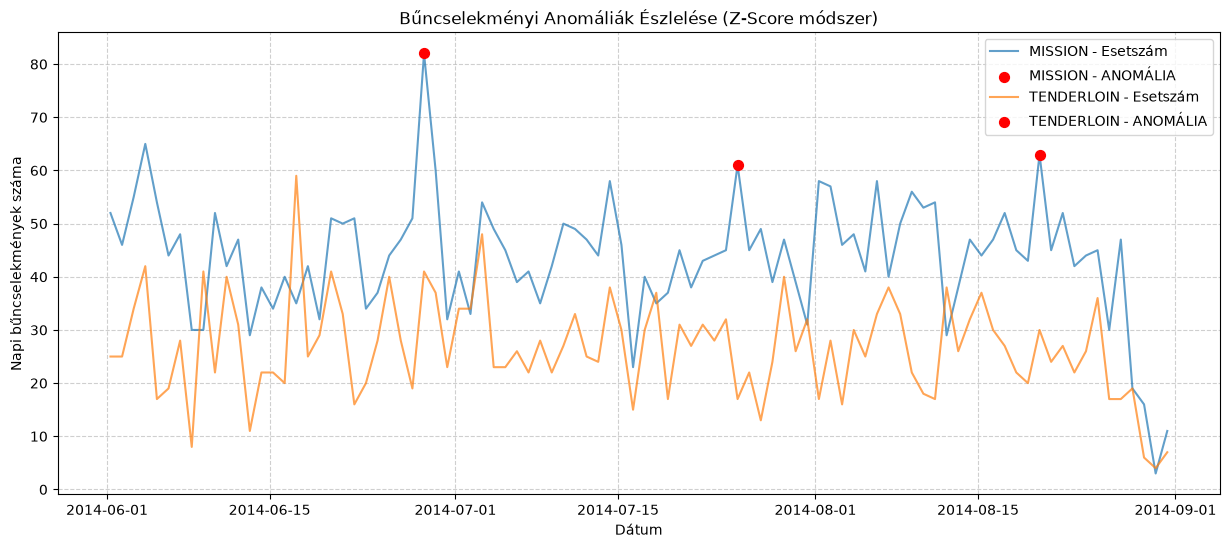

C:\Users\Máté\AppData\Local\Temp\ipykernel_9720\166996828.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PdDistrict', y='Count', data=daily_dist_crimes, palette='viridis')


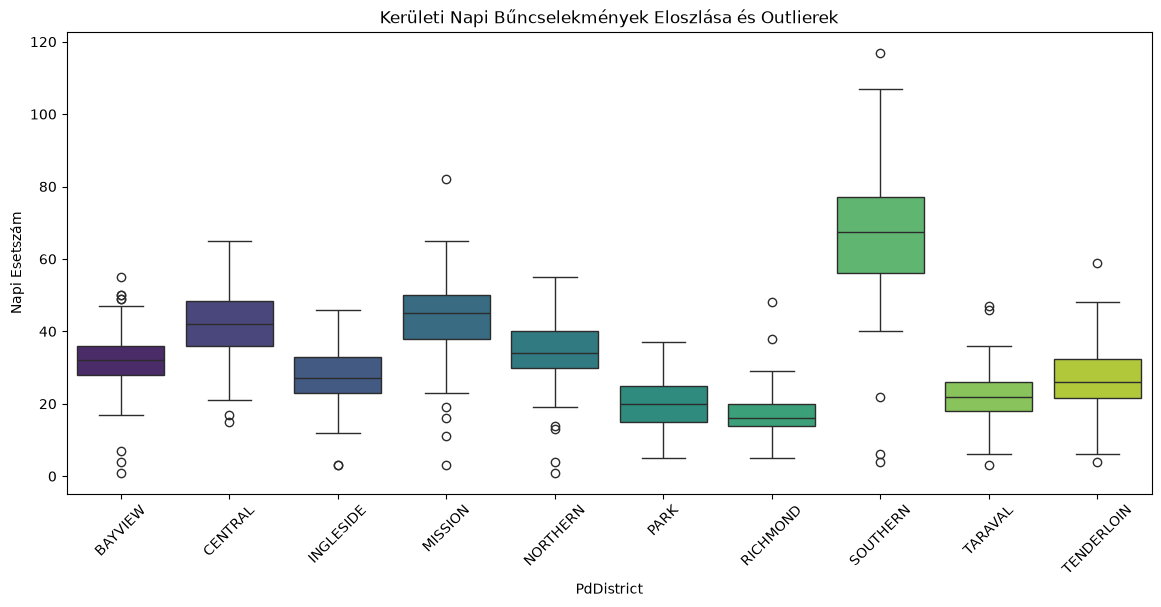

In [39]:
# --- 7. ANOMÁLIA ÉSZLELÉS (STATISZTIKAI ALAPON) ÉS VIZUALIZÁCIÓ ---
print("\n[!] Valós idejű statisztikai anomália észlelés futtatása...")
import matplotlib.pyplot as plt
import seaborn as sns

# Napi esetszámok kiszámítása kerületenként
daily_dist_crimes = df.groupby(['Date', 'PdDistrict']).size().reset_index(name='Count')

# Anomáliák keresése: 7 napos mozgóátlag és szórás kiszámítása
daily_dist_crimes['Rolling_Mean'] = daily_dist_crimes.groupby('PdDistrict')['Count'].transform(lambda x: x.rolling(7, min_periods=1).mean())
daily_dist_crimes['Rolling_Std'] = daily_dist_crimes.groupby('PdDistrict')['Count'].transform(lambda x: x.rolling(7, min_periods=1).std().fillna(0))

# Z-score alapú szűrés (ha a napi szám > átlag + 2 * szórás, az anomália)
daily_dist_crimes['Is_Anomaly'] = daily_dist_crimes['Count'] > (daily_dist_crimes['Rolling_Mean'] + 2 * daily_dist_crimes['Rolling_Std'])
anomalies = daily_dist_crimes[daily_dist_crimes['Is_Anomaly']]

print(f"Összesen {len(anomalies)} anomáliás napot találtunk a kerületekben.")

# Anomáliás rekordok megjelenítése
from IPython.display import display
display(anomalies)

# Vizualizáció: Anomáliák ábrázolása a 'MISSION' és 'TENDERLOIN' kerületekre példaként
plt.figure(figsize=(15, 6))
sample_districts = ['MISSION', 'TENDERLOIN']

for dist in sample_districts:
    dist_data = daily_dist_crimes[daily_dist_crimes['PdDistrict'] == dist]
    dist_anomalies = dist_data[dist_data['Is_Anomaly']]
    
    plt.plot(dist_data['Date'], dist_data['Count'], label=f'{dist} - Esetszám', alpha=0.7)
    # Anomáliák jelölése piros pontokkal
    plt.scatter(dist_anomalies['Date'], dist_anomalies['Count'], color='red', s=50, zorder=5, label=f'{dist} - ANOMÁLIA')

plt.title('Bűncselekményi Anomáliák Észlelése (Z-Score módszer)')
plt.xlabel('Dátum')
plt.ylabel('Napi bűncselekmények száma')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Boxplot az összes kerület eloszlásának és az outliereknek a bemutatására
plt.figure(figsize=(14, 6))
sns.boxplot(x='PdDistrict', y='Count', data=daily_dist_crimes, palette='viridis')
plt.title('Kerületi Napi Bűncselekmények Eloszlása és Outlierek')
plt.xticks(rotation=45)
plt.ylabel('Napi Esetszám')
plt.show()


In [40]:
# --- 8. ANIMÁLT HŐTÉRKÉP A HOLNAPI PREDIKCIÓKHOZ ---
from folium.plugins import HeatMapWithTime
print("\nAnimált Idősoros Hőtérkép (HeatMapWithTime) generálása a szimulált napra...")

# A szimulált adatok (pred_df) órák szerinti csoportosítása
# Hozzuk létre a lista-listáját: minden órához (0-23) egy lista a [lat, lon, súly] értékekről
hour_data = []
hour_index = []

for h in range(24):
    h_data = pred_df[pred_df['Hour'] == h]
    if len(h_data) > 0:
        # A súly mindenhol 1 (egy esemény = 1 súly)
        hour_coords = [[row['Y'], row['X'], 1] for idx, row in h_data.iterrows()]
        hour_data.append(hour_coords)
        hour_index.append(f"{h:02d}:00")

if len(hour_data) > 0:
    # Új térkép inicializálása
    m_animated = folium.Map(location=[37.77, -122.42], zoom_start=12, tiles='CartoDB Dark_Matter')

    # Animált HeatMap hozzáadása
    HeatMapWithTime(
        data=hour_data,
        index=hour_index,
        radius=15,
        auto_play=True,
        max_opacity=0.8,
        gradient={0.2: 'blue', 0.5: 'yellow', 1.0: 'red'}
    ).add_to(m_animated)

    print("Kész! A lejátszás gombbal (Play) megtekinthető a bűncselekmények napi vándorlása.")
else:
    m_animated = "Nincs elegendő adat az animációhoz."

# Térkép megjelenítése
m_animated



Animált Idősoros Hőtérkép (HeatMapWithTime) generálása a szimulált napra...
Kész! A lejátszás gombbal (Play) megtekinthető a bűncselekmények napi vándorlása.
